In [2]:
import numpy as np
import sympy as sp
import control as ct
import matplotlib.pyplot as plt
import scipy.signal
import scipy.linalg
import cvxpy as cp
from sympy.physics.mechanics import dynamicsymbols

In [3]:
t = sp.Symbol('t')
x, th1, th2 = dynamicsymbols('x theta1 theta2')
u = sp.Symbol('u')
M, m1, m2, L1, L2, g = sp.symbols('M m1 m2 L1 L2 g', positive=True)
delta, c1, c2 = sp.symbols('delta c1 c2', nonnegative=True)

q = sp.Matrix([x, th1, th2])
qd = q.diff(t)
qdd = qd.diff(t)

In [4]:
p0 = sp.Matrix([x, 0])                                        # cart
p1 = p0 + L1 * sp.Matrix([sp.sin(th1),  sp.cos(th1)])          # mass 1
p2 = p1 + L2 * sp.Matrix([sp.sin(th2),  sp.cos(th2)])          # mass 2
 
v0, v1, v2 = p0.diff(t), p1.diff(t), p2.diff(t)

In [5]:
T = sp.Rational(1, 2) * (M * v0.dot(v0) + m1 * v1.dot(v1) + m2 * v2.dot(v2))
V = g * (m1 * p1[1] + m2 * p2[1])
T, V = sp.simplify(T), sp.simplify(V)
Lag = T - V

In [6]:
Q = sp.Matrix([u - delta * x.diff(t),          # actuator + cart friction
               -c1 * th1.diff(t),              # joint damping (0 by default)
               -c2 * th2.diff(t)])
 
EL = sp.Matrix([sp.diff(Lag, qd[i], t) - sp.diff(Lag, q[i]) - Q[i]
                for i in range(3)])
EL = sp.simplify(sp.trigsimp(EL))

In [7]:
D, rhs = sp.linear_eq_to_matrix(EL, list(qdd))   # D*qdd = rhs
D = sp.simplify(D)
rhs = sp.simplify(rhs)

G = sp.simplify(sp.Matrix([sp.diff(V, q[i]) for i in range(3)]))
CqdG = sp.simplify(-rhs + Q)          # = C(q,qd)*qd + G(q)
Cqd = sp.simplify(CqdG - G)

In [8]:
acc = sp.simplify(D.LUsolve(rhs))

In [9]:
xs, t1s, t2s, dxs, dt1s, dt2s = sp.symbols('x_ th1_ th2_ dx_ dth1_ dth2_')
sub_map = {x.diff(t): dxs, th1.diff(t): dt1s, th2.diff(t): dt2s,
           x: xs, th1: t1s, th2: t2s}
 
X = sp.Matrix([xs, t1s, t2s, dxs, dt1s, dt2s])
f = sp.Matrix([dxs, dt1s, dt2s,
               *[a.subs(sub_map) for a in acc]])

A_sym = f.jacobian(X)
B_sym = f.jacobian(sp.Matrix([u]))
 
up = {xs: 0, t1s: 0, t2s: 0, dxs: 0, dt1s: 0, dt2s: 0, u: 0}   # upright
A_up = sp.simplify(A_sym.subs(up))
B_up = sp.simplify(B_sym.subs(up))
 
down = {xs: 0, t1s: sp.pi, t2s: sp.pi, dxs: 0, dt1s: 0, dt2s: 0, u: 0}
A_dn = sp.simplify(A_sym.subs(down))
B_dn = sp.simplify(B_sym.subs(down))


In [24]:
params = {M : 10, m1 : 1, m2 : 1, L1 : 0.5, L2 : 0.5, delta : 1, g : 10, c1 : 0.001, c2 : 0.001}

A = A_up.subs(params)
B = B_up.subs(params)

A = np.array(A).astype(np.float64)
B = np.array(B).astype(np.float64)

dt = 0.01
Cc = np.zeros((3, 6)); Cc[0,0] = Cc[1,1] = Cc[2,2] = 1.0

sys = scipy.signal.StateSpace(A,B,Cc,np.zeros((3,1)))
sysd = sys.to_discrete(dt)

Ad = sysd.A
Bd = sysd.B
Cd = sysd.C
Dd = sysd.D

Q = np.diag([1,1,1,1,1,1])
R = np.array([0.01])

K, S, E = ct.dlqr(Ad, Bd, Q, R)

sigma_meas = np.array([0.01, np.radians(0.5), np.radians(0.5)])
Vn = np.diag(sigma_meas**2)
sigma_w = 0.5
Vd = (sigma_w**2) * (Bd @ Bd.T) + 1e-8*np.eye(6)

In [29]:
f_num = sp.lambdify((xs, t1s, t2s, dxs, dt1s, dt2s, u), f.subs(params), 'numpy')

def nonlinear_dynamics(t, statevec, uval, wforce=0.0):
    d = np.asarray(f_num(*statevec, uval)).flatten()
    d[3] += wforce
    return d

rng = np.random.default_rng(0)
x_true = np.array([0.0, 0.0, 0.1, 0.0, 0.0, 0.0])
x_hat  = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])   # filter starts wrong
Pk     = np.diag([0.01, 0.01, 0.01, 0.1, 0.1, 0.1])

tfinal = 20.0; nsteps = int(tfinal/dt)
t_h=[0.0]; xt_h=[x_true.copy()]; xh_h=[x_hat.copy()]; u_h=[]; y_h=[]; tr_h=[np.trace(Pk)]

for k in range(nsteps):
    uval = float((-K @ x_hat).item())          # <-- feedback on ESTIMATE
    wf = sigma_w * rng.standard_normal() / np.sqrt(dt)
    sol = scipy.integrate.solve_ivp(nonlinear_dynamics, [0, dt], x_true,
                                    args=(uval, wf), method='RK45', max_step=dt/10)
    x_true = sol.y[:, -1]
    y = Cd @ x_true + sigma_meas * rng.standard_normal(3)

    x_hat = Ad @ x_hat + (Bd * uval).flatten()   # --- predict ---
    Pk    = Ad @ Pk @ Ad.T + Vd

    S  = Cd @ Pk @ Cd.T + Vn                     # --- update ---
    Lk = Pk @ Cd.T @ np.linalg.inv(S)
    x_hat = x_hat + Lk @ (y - Cd @ x_hat)
    I_LC  = np.eye(6) - Lk @ Cd
    Pk    = I_LC @ Pk @ I_LC.T + Lk @ Vn @ Lk.T  # Joseph form

    t_h.append(t_h[-1]+dt); xt_h.append(x_true.copy()); xh_h.append(x_hat.copy())
    u_h.append(uval); y_h.append(y); tr_h.append(np.trace(Pk))

t_hist=np.array(t_h); xt_hist=np.array(xt_h); xh_hist=np.array(xh_h)
u_hist=np.array(u_h); y_hist=np.array(y_h); tr_hist=np.array(tr_h)
err = xt_hist - xh_hist

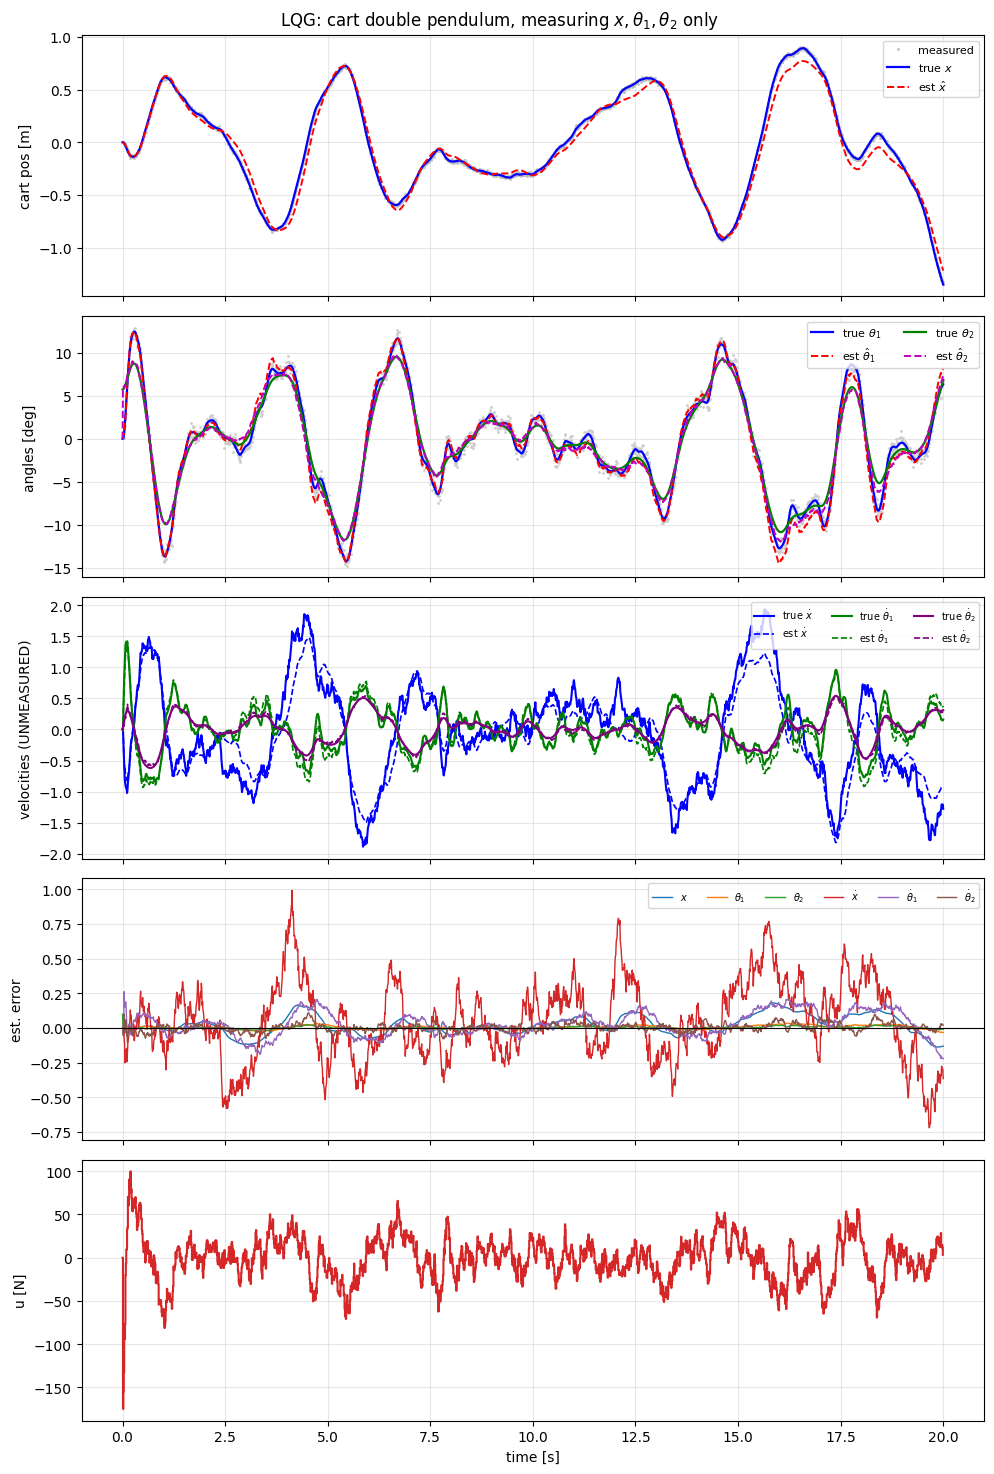

In [30]:
fig, axs = plt.subplots(5,1, figsize=(10,15), sharex=True)

axs[0].plot(t_hist[1:], y_hist[:,0], '.', ms=2, color='0.75', label='measured')
axs[0].plot(t_hist, xt_hist[:,0], 'b-',  lw=1.6, label='true $x$')
axs[0].plot(t_hist, xh_hist[:,0], 'r--', lw=1.4, label='est $\\hat{x}$')
axs[0].set_ylabel('cart pos [m]'); axs[0].legend(loc='upper right',fontsize=8); axs[0].grid(alpha=.3)

axs[1].plot(t_hist[1:], np.degrees(y_hist[:,1]), '.', ms=2, color='0.8')
axs[1].plot(t_hist, np.degrees(xt_hist[:,1]), 'b-',  lw=1.6, label='true $\\theta_1$')
axs[1].plot(t_hist, np.degrees(xh_hist[:,1]), 'r--', lw=1.4, label='est $\\hat{\\theta}_1$')
axs[1].plot(t_hist, np.degrees(xt_hist[:,2]), 'g-',  lw=1.6, label='true $\\theta_2$')
axs[1].plot(t_hist, np.degrees(xh_hist[:,2]), 'm--', lw=1.4, label='est $\\hat{\\theta}_2$')
axs[1].set_ylabel('angles [deg]'); axs[1].legend(loc='upper right',fontsize=8,ncol=2); axs[1].grid(alpha=.3)

for i,(lb,cc) in enumerate(zip([r'$\dot x$',r'$\dot\theta_1$',r'$\dot\theta_2$'],['b','g','purple'])):
    axs[2].plot(t_hist, xt_hist[:,3+i], color=cc, lw=1.5, label='true '+lb)
    axs[2].plot(t_hist, xh_hist[:,3+i], color=cc, ls='--', lw=1.2, label='est '+lb)
axs[2].set_ylabel('velocities (UNMEASURED)'); axs[2].legend(loc='upper right',fontsize=7,ncol=3); axs[2].grid(alpha=.3)

for i,lb in enumerate(['$x$',r'$\theta_1$',r'$\theta_2$',r'$\dot x$',r'$\dot\theta_1$',r'$\dot\theta_2$']):
    axs[3].plot(t_hist, err[:,i], lw=1, label=lb)
axs[3].axhline(0,color='k',lw=.8); axs[3].set_ylabel('est. error')
axs[3].legend(loc='upper right',fontsize=7,ncol=6); axs[3].grid(alpha=.3)

axs[4].step(t_hist[:-1], u_hist, where='post', color='tab:red')
axs[4].set_ylabel('u [N]'); axs[4].set_xlabel('time [s]'); axs[4].grid(alpha=.3)

fig.suptitle('LQG: cart double pendulum, measuring $x,\\theta_1,\\theta_2$ only')
fig.tight_layout(); plt.show()